In [3]:
import fiona
import geopandas as gpd
import pandas as pd

In [4]:
GPKG_PATH = "../data/raw/coastlines.gpkg" 

In [6]:
layers = fiona.listlayers(GPKG_PATH)
print(f"Found {len(layers)} layer(s):")
for l in layers:
    print(" -", l)

Found 6 layer(s):
 - shorelines_annual
 - rates_of_change
 - hotspots_zoom_1
 - hotspots_zoom_2
 - hotspots_zoom_3
 - layer_styles


In [10]:
target_layer = layers[0]
 
with fiona.open(GPKG_PATH, layer=target_layer) as src:
    print("CRS:", src.crs)
    print("Feature count:", len(src))
    print("Schema fields:")
    for field, dtype in src.schema["properties"].items():
        print(f"  {field}: {dtype}")
    # Look at ONE feature's attributes to understand the actual values
    first = next(iter(src))
    print("\nSample feature properties:")
    print(first["properties"])

CRS: EPSG:3832
Feature count: 22444
Schema fields:
  year: float
  certainty: str
  eez_territory: str

Sample feature properties:
fiona.Properties(year=1999.0, certainty='insufficient data', eez_territory='PYF')


In [13]:
with fiona.open(GPKG_PATH, layer="shorelines_annual") as src:
    codes = set()
    for feature in src:
        territory = feature["properties"]["eez_territory"]
        if territory is not None:
            codes.add(territory)
print(sorted(codes))

['ASM', 'COK', 'FJI', 'FSM', 'GUM', 'KIR', 'MHL', 'MNP', 'NCL', 'NIU', 'NRU', 'PCN', 'PLW', 'PNG', 'PYF', 'SLB', 'TKL', 'TON', 'TUV', 'VUT', 'WLF', 'WSM']


In [14]:
MY_CODES = ["FJI", "KIR", "WSM", "TUV", "VUT"]
codes_str = ", ".join(f"'{c}'" for c in MY_CODES)

gdf = gpd.read_file(
    GPKG_PATH,
    layer="shorelines_annual",
    where=f"eez_territory IN ({codes_str})"
)
print(gdf.shape)
gdf.head()

c:\Users\msche\anaconda3\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files.  Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


(4250, 4)


,year,certainty,eez_territory,geometry
0,2000.0,insufficient data,FJI,"MULTILINESTRING ((3479031.445 -2378307.075, 34..."
1,2001.0,insufficient data,FJI,"MULTILINESTRING ((3479030.532 -2378307.065, 34..."
2,2002.0,insufficient data,FJI,"MULTILINESTRING ((3479033.255 -2378307.095, 34..."
3,2003.0,insufficient data,FJI,"MULTILINESTRING ((3479032.477 -2378307.086, 34..."
4,2004.0,insufficient data,FJI,"MULTILINESTRING ((3479058.683 -2377888.384, 34..."


In [15]:
print(gdf["certainty"].value_counts())

certainty
good                 1825
insufficient data    1638
unstable data         787
Name: count, dtype: int64


In [18]:
before = len(gdf)
gdf_good = gdf[gdf["certainty"] == "good"].copy()
after = len(gdf_good)
print(f"Kept {after}/{before} rows ({after/before:.1%}) after certainty filter")

Kept 1825/4250 rows (42.9%) after certainty filter


In [20]:
print(gdf_good.groupby("eez_territory").size())

eez_territory
FJI    662
KIR    554
TUV    162
VUT    360
WSM     87
dtype: int64


In [21]:
year_coverage = gdf_good.groupby("eez_territory")["year"].agg(["min", "max", "nunique"])
year_coverage

,min,max,nunique
eez_territory,,,
FJI,1999.0,2023.0,25
KIR,1999.0,2023.0,25
TUV,2000.0,2023.0,24
VUT,2000.0,2023.0,24
WSM,1999.0,2023.0,25


In [22]:
gdf_good["length_km"] = gdf_good.geometry.length / 1000
 
coastline_by_year = (
    gdf_good.groupby(["eez_territory", "year"])["length_km"]
    .sum()
    .reset_index()
    .sort_values(["eez_territory", "year"])
)
coastline_by_year

,eez_territory,year,length_km
0,FJI,1999.0,159.057425
1,FJI,2000.0,1105.270873
2,FJI,2001.0,1927.669789
3,FJI,2002.0,2668.671070
4,FJI,2003.0,3357.946253
...,...,...,...
118,WSM,2019.0,454.351053
119,WSM,2020.0,463.322410
120,WSM,2021.0,495.532820
121,WSM,2022.0,487.886374


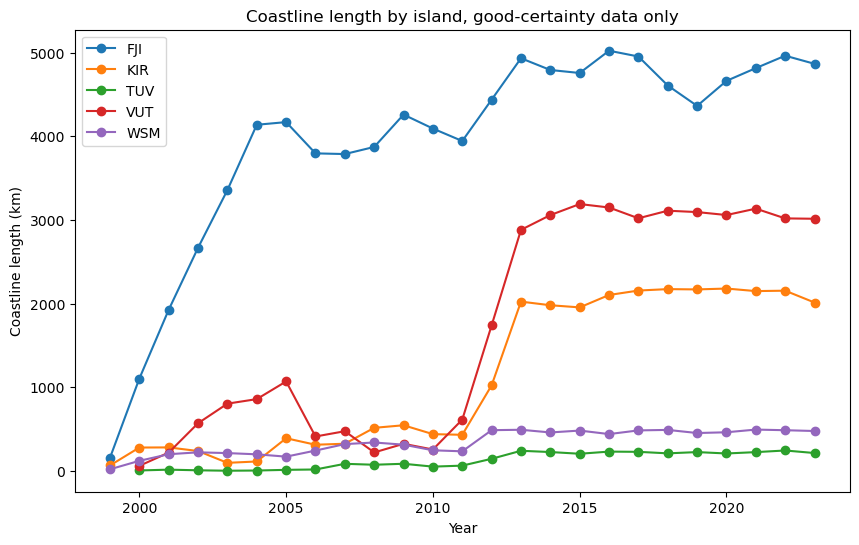

In [23]:
import matplotlib.pyplot as plt
 
fig, ax = plt.subplots(figsize=(10, 6))
for territory, group in coastline_by_year.groupby("eez_territory"):
    ax.plot(group["year"], group["length_km"], marker="o", label=territory)
ax.set_xlabel("Year")
ax.set_ylabel("Coastline length (km)")
ax.legend()
ax.set_title("Coastline length by island, good-certainty data only")
plt.show()

In [24]:
with fiona.open(GPKG_PATH, layer="rates_of_change") as src:
    print("Feature count:", len(src))
    print("Schema fields:")
    for field, dtype in src.schema["properties"].items():
        print(f"  {field}: {dtype}")
    print("\nSample:", next(iter(src))["properties"])

Feature count: 2057082
Schema fields:
  uid: str
  rate_time: float
  sig_time: float
  se_time: float
  outl_time: str
  dist_1999: float
  dist_2000: float
  dist_2001: float
  dist_2003: float
  dist_2004: float
  dist_2005: float
  dist_2006: float
  dist_2007: float
  dist_2008: float
  dist_2009: float
  dist_2010: float
  dist_2011: float
  dist_2012: float
  dist_2013: float
  dist_2014: float
  dist_2015: float
  dist_2016: float
  dist_2017: float
  dist_2018: float
  dist_2019: float
  dist_2020: float
  dist_2021: float
  dist_2022: float
  dist_2023: float
  angle_mean: int32
  angle_std: int32
  valid_obs: int32
  valid_span: int32
  sce: float
  nsm: float
  max_year: int32
  min_year: int32
  certainty: str
  eez_territory: str
  dist_2002: float

Sample: fiona.Properties(uid='2g175srx6w', rate_time=8.818, sig_time=0.264, se_time=7.642, outl_time='2000 2003 2004 2011 2014', dist_1999=10.05, dist_2000=None, dist_2001=-1.09, dist_2003=-3715.94, dist_2004=-1052.87, dist_20

In [25]:
rates_gdf = gpd.read_file(GPKG_PATH, layer="rates_of_change",where=f"eez_territory IN ({codes_str})")
rates_gdf.head()

,uid,rate_time,sig_time,se_time,outl_time,dist_1999,dist_2000,dist_2001,dist_2003,dist_2004,...,valid_obs,valid_span,sce,nsm,max_year,min_year,certainty,eez_territory,dist_2002,geometry
0,2h2bkqnvng,1.076,0.004,0.323,,NaN,-11.74,-11.40,-18.52,-18.53,...,21,24,52.32,NaN,2015,2010,good,FJI,-24.72,POINT (3478847.6 -2378465.69)
1,2h2bkqpjt5,0.942,0.000,0.150,2010 2011,NaN,-10.61,-13.09,-17.85,-18.72,...,19,24,23.40,NaN,2015,2002,good,FJI,-19.89,POINT (3478878.04 -2378455.797)
2,2h2bkqpq5r,1.001,0.000,0.221,2010 2011,NaN,-5.60,-11.58,-19.06,-25.35,...,19,24,29.22,NaN,2015,2004,good,FJI,-16.65,POINT (3478907.37 -2378442.742)
3,2h2bkqpwcr,1.162,0.007,0.381,2010,NaN,-1.67,-6.56,-20.20,-37.75,...,20,24,41.04,NaN,2015,2004,good,FJI,-13.55,POINT (3478935.692 -2378427.652)
4,2h2bkqpxyf,0.474,0.022,0.186,2004 2005 2007 2010,NaN,-0.19,-1.37,-23.82,-48.06,...,17,24,26.49,NaN,2021,2003,good,FJI,-9.46,POINT (3478962.865 -2378410.551)


In [26]:
before = len(rates_gdf)
rates_good = rates_gdf[rates_gdf["certainty"] == "good"].copy()
print(f"Kept {len(rates_good)}/{before} ({len(rates_good)/before:.1%})")
print(rates_good.groupby("eez_territory").size())

Kept 189781/365785 (51.9%)
eez_territory
FJI    121173
KIR     30670
TUV      4384
VUT     24053
WSM      9501
dtype: int64


In [27]:
print(rates_good.groupby("eez_territory")["rate_time"].describe())

                  count      mean       std     min      25%     50%     75%  \
eez_territory                                                                  
FJI            121173.0  0.046240  1.425631 -91.237 -0.22700  0.0060  0.2590   
KIR             30670.0  0.064568  3.033807 -32.598 -0.45000 -0.1570  0.1400   
TUV              4384.0  0.355921  1.293110 -18.687 -0.11025  0.1985  0.6065   
VUT             24053.0  0.090097  2.395470 -26.208 -0.22200 -0.0130  0.2170   
WSM              9501.0  0.237221  2.178912 -58.390 -0.12000  0.1010  0.3100   

                   max  
eez_territory           
FJI            112.386  
KIR             99.432  
TUV             21.728  
VUT             83.366  
WSM             33.975  


In [28]:
sig_share = (
    rates_good.assign(is_significant=rates_good["sig_time"] < 0.05)
    .groupby("eez_territory")["is_significant"]
    .mean()
)
print("Share of points with statistically significant trend, per island:")
print(sig_share)

Share of points with statistically significant trend, per island:
eez_territory
FJI    0.428957
KIR    0.506978
TUV    0.431797
VUT    0.374714
WSM    0.510052
Name: is_significant, dtype: float64


In [31]:
coastline_risk = (
    rates_good.groupby("eez_territory")
    .agg(
        median_rate_m_per_yr=("rate_time", "median"),   # primary signal — robust to outliers
        pct_eroding=("rate_time", lambda x: (x < 0).mean()),  # primary signal — share retreating
        mean_rate_m_per_yr=("rate_time", "mean"),        # kept for reference/diagnostics only
        n_points=("rate_time", "count"),
    )
    .reset_index()
    .rename(columns={"eez_territory": "geo_pict"})
)
coastline_risk


,geo_pict,median_rate_m_per_yr,pct_eroding,mean_rate_m_per_yr,n_points
0,FJI,0.0060,0.492040,0.046240,121173
1,KIR,-0.1570,0.641050,0.064568,30670
2,TUV,0.1985,0.329836,0.355921,4384
3,VUT,-0.0130,0.514614,0.090097,24053
4,WSM,0.1010,0.367225,0.237221,9501


In [32]:
print(coastline_risk.sort_values("mean_rate_m_per_yr"))

  geo_pict  median_rate_m_per_yr  pct_eroding  mean_rate_m_per_yr  n_points
0      FJI                0.0060     0.492040            0.046240    121173
1      KIR               -0.1570     0.641050            0.064568     30670
3      VUT               -0.0130     0.514614            0.090097     24053
4      WSM                0.1010     0.367225            0.237221      9501
2      TUV                0.1985     0.329836            0.355921      4384


In [33]:
import os
os.makedirs("../data/processed", exist_ok=True)
coastline_risk.to_csv("../data/processed/coastline_risk_by_country.csv", index=False)
print("Saved coastline_risk_by_country.csv")

Saved coastline_risk_by_country.csv
